In [6]:
import pandas as pd
df = pd.read_csv("cardio_train (1).csv")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [3]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [4]:
df = df.dropna()

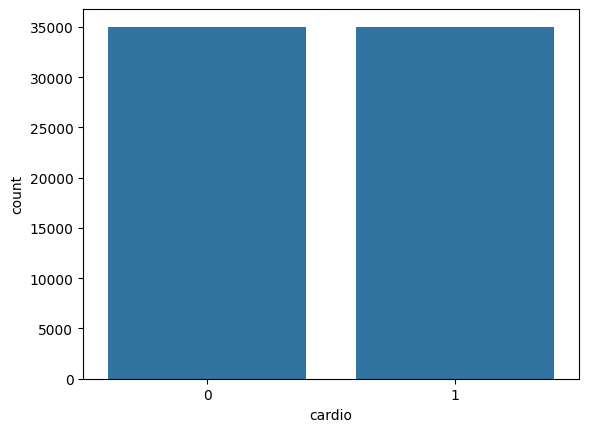

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cardio', data=df)
plt.show()

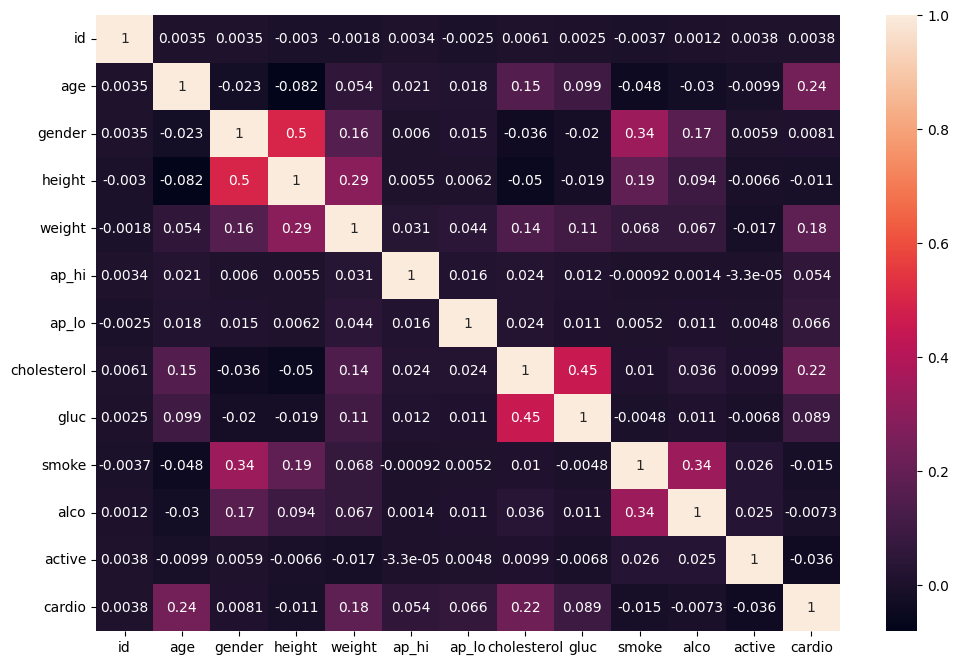

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("Accuracy:", rf.score(X_test, y_test))

Accuracy: 0.7245


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_acc = lr.score(X_test, y_test)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7229285714285715


In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_acc = knn.score(X_test, y_test)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6255714285714286


In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_acc = dt.score(X_test, y_test)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6365714285714286


In [7]:
X = df.drop('cardio', axis=1)
y = df['cardio']

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [9]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

print("SVM Accuracy:", svm.score(X_test, y_test))

SVM Accuracy: 0.7318571428571429


In [18]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Accuracy': [lr_acc, knn_acc, dt_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.722929
1                  KNN  0.625571
2        Decision Tree  0.636571
